In [21]:
import pandas as pd

In [22]:
df = pd.read_csv("../data/insurance_data.csv")

In [23]:
df

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1340 non-null   int64  
 1   PatientID      1340 non-null   int64  
 2   age            1335 non-null   float64
 3   gender         1340 non-null   object 
 4   bmi            1340 non-null   float64
 5   bloodpressure  1340 non-null   int64  
 6   diabetic       1340 non-null   object 
 7   children       1340 non-null   int64  
 8   smoker         1340 non-null   object 
 9   region         1337 non-null   object 
 10  claim          1340 non-null   float64
dtypes: float64(3), int64(4), object(4)
memory usage: 115.3+ KB


In [25]:
df.isnull().sum()

index            0
PatientID        0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [26]:
df["age"]= df["age"].fillna(df["age"].median())

In [27]:
df["region"] = df["region"].fillna(df["region"].mode()[0])

In [28]:
df.isnull().sum()

index            0
PatientID        0
age              0
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           0
claim            0
dtype: int64

In [29]:
df["region"].unique()

array(['southeast', 'northwest', 'southwest', 'northeast'], dtype=object)

In [30]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"
df["bmi_category"] = df["bmi"].apply(bmi_category)

In [31]:
print(df[["bmi","bmi_category"]] )

       bmi bmi_category
0     23.2       Normal
1     30.1        Obese
2     33.3        Obese
3     33.7        Obese
4     34.1        Obese
...    ...          ...
1335  35.5        Obese
1336  38.1        Obese
1337  34.5        Obese
1338  30.4        Obese
1339  47.4        Obese

[1340 rows x 2 columns]


In [32]:
df.head(1)

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,bmi_category
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87,Normal


In [33]:
df.head(1)

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,bmi_category
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87,Normal


In [34]:
df.drop(["index","PatientID"],axis =1)

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,bmi_category
0,39.0,male,23.2,91,Yes,0,No,southeast,1121.87,Normal
1,24.0,male,30.1,87,No,0,No,southeast,1131.51,Obese
2,38.0,male,33.3,82,Yes,0,No,southeast,1135.94,Obese
3,38.0,male,33.7,80,No,0,No,northwest,1136.40,Obese
4,38.0,male,34.1,100,No,0,No,northwest,1137.01,Obese
...,...,...,...,...,...,...,...,...,...,...
1335,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40,Obese
1336,59.0,female,38.1,120,No,1,Yes,northeast,58571.07,Obese
1337,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40,Obese
1338,37.0,male,30.4,106,No,0,Yes,southeast,62592.87,Obese


In [35]:
df["smoker"] = df["smoker"].str.lower()
df["diabetic"] = df["diabetic"].str.lower()
df["gender"] = df["gender"].str.lower()
df["region"] = df["region"].str.lower()

In [36]:
df = pd.get_dummies(df,columns =["gender","smoker","diabetic","region","bmi_category"],drop_first=True)

In [37]:
df.head(1)

,index,PatientID,age,bmi,bloodpressure,children,claim,gender_male,smoker_yes,diabetic_yes,region_northwest,region_southeast,region_southwest,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight
0,0,1,39.0,23.2,91,0,1121.87,1,0,1,0,1,0,0,0,0


In [38]:
df.shape

(1340, 16)

In [39]:
X= df.drop("claim",axis=1)
y=df["claim"]

In [40]:
X.isnull().sum().sum()

0

In [41]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state=42
)

In [42]:
print(X_test.shape)

(268, 15)


In [43]:
numeric_cols= ["age","bmi","bloodpressure","children"]

In [44]:
from sklearn.preprocessing import StandardScaler

In [45]:
scaler= StandardScaler()

In [46]:
X_train[numeric_cols]=scaler.fit_transform(X_train[numeric_cols])

In [47]:
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [48]:
X_train.head()

,index,PatientID,age,bmi,bloodpressure,children,gender_male,smoker_yes,diabetic_yes,region_northwest,region_southeast,region_southwest,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight
1148,1148,1149,-0.567256,-0.625657,1.811052,-0.073023,1,1,1,1,0,0,0,1,0
807,807,808,1.152583,-0.789196,-0.972760,-0.905796,0,0,1,1,0,0,0,1,0
1287,1287,1288,-0.567256,1.385867,0.158164,-0.905796,0,1,1,1,0,0,1,0,0
590,590,591,-0.024149,-1.165334,0.158164,1.592523,0,0,1,0,0,0,0,0,0
1188,1188,1189,-0.114667,-0.363995,-0.537789,1.592523,1,1,0,1,0,0,0,1,0


In [49]:
from sklearn.linear_model import LinearRegression

In [50]:
lr_model= LinearRegression()

In [51]:
lr_model.fit(X_train,y_train)

LinearRegression()

In [52]:
y_pred = lr_model.predict(X_test)

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [54]:
mae = mean_absolute_error(y_test,y_pred)
rmse= mean_squared_error(y_test,y_pred) ** 0.5
r2 = r2_score(y_test,y_pred)

print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 3210.8222979831994
RMSE: 4400.963194179578
R2: 0.8821131504403695


In [55]:
from xgboost import XGBRegressor

In [56]:
xgb_model = XGBRegressor(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 4,
    random_state = 42
)

In [57]:
xgb_model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [58]:
xgb_pred=xgb_model.predict(X_test)

In [59]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = mean_squared_error(y_test, xgb_pred) ** 0.5
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2:", xgb_r2)

XGBoost MAE: 109.42198171131652
XGBoost RMSE: 479.21402953646407
XGBoost R2: 0.998602251816004


In [60]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance.sort_values(by="Importance", ascending=False).head(10)

,Feature,Importance
0,index,0.995371
4,bloodpressure,0.001568
2,age,0.001189
5,children,0.000912
6,gender_male,0.000254
3,bmi,0.000214
13,bmi_category_Overweight,0.000135
7,smoker_yes,0.000134
11,region_southwest,0.000074
10,region_southeast,0.000069


In [61]:
df.corr(numeric_only=True)["claim"].sort_values(ascending=False)

claim                       1.000000
index                       0.879268
PatientID                   0.879268
smoker_yes                  0.787279
bloodpressure               0.531341
bmi_category_Obese          0.199288
bmi                         0.197401
children                    0.069233
gender_male                 0.055766
diabetic_yes               -0.008725
region_southeast           -0.015966
region_southwest           -0.024204
age                        -0.027830
bmi_category_Underweight   -0.044747
region_northwest           -0.077490
bmi_category_Overweight    -0.119018
Name: claim, dtype: float64

In [62]:
df = df.drop(["index", "PatientID"], axis=1)

In [63]:
df.columns

Index(['age', 'bmi', 'bloodpressure', 'children', 'claim', 'gender_male',
       'smoker_yes', 'diabetic_yes', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Obese', 'bmi_category_Overweight',
       'bmi_category_Underweight'],
      dtype='object')

In [64]:
X = df.drop("claim", axis=1)
y = df["claim"]

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
numeric_cols = ["age", "bmi", "bloodpressure", "children"]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [66]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = mean_squared_error(y_test, xgb_pred) ** 0.5
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2:", xgb_r2)

XGBoost MAE: 3779.2852131311224
XGBoost RMSE: 5108.630343470541
XGBoost R2: 0.8411530626484247


In [68]:
from sklearn.model_selection import cross_val_score

In [69]:
cv_scores = cross_val_score(
    lr_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(cv_scores)

[-90.07941199 -19.7378999   -7.06469016 -10.80185331  -2.85271565]


In [70]:
print("Average R2:", cv_scores.mean())

Average R2: -26.107314200080587


In [71]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [74]:
numeric_cols = ["age", "bmi", "bloodpressure", "children"]

In [75]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols)
    ],
    remainder="passthrough"
)

In [76]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [77]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(cv_scores)
print("Average R2:", cv_scores.mean())

[-90.07941199 -19.7378999   -7.06469016 -10.80185331  -2.85271565]
Average R2: -26.107314200080573


In [78]:
from sklearn.model_selection import KFold

In [79]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [80]:
cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print(cv_scores)
print("Average R2:", cv_scores.mean())

[0.73722325 0.70121283 0.62727573 0.66947103 0.75117747]
Average R2: 0.6972720613753942


In [81]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [83]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [84]:
import shap

ModuleNotFoundError: No module named 'shap'

In [85]:
import sys
print(sys.executable)

C:\Users\Nasar\anaconda3\python.exe


In [86]:
import sys
!{sys.executable} -m pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/547.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/547.0 kB ? eta -:--:--
   -------------------------------------- 547.0/547.0 kB 701.7 kB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: C:\Users\Nasar\anaconda3\python.exe -m pip install --upgrade pip


In [87]:
import shap

In [88]:
explainer = shap.TreeExplainer(xgb_model)

In [89]:
shap_values = explainer.shap_values(X_test)

In [90]:
shap_values.shape

(268, 13)

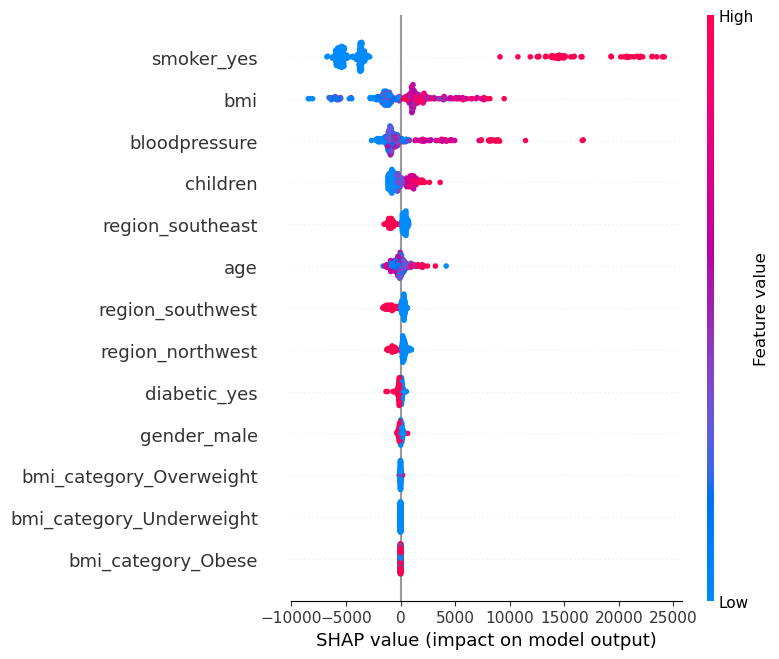

In [91]:
shap.summary_plot(shap_values, X_test)

In [93]:
import numpy as np
import pandas as pd

shap_abs_mean = np.abs(shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "shap_importance": shap_abs_mean
}).sort_values(by="shap_importance", ascending=False)

feature_importance

,feature,shap_importance
5,smoker_yes,7288.723145
1,bmi,2330.930420
2,bloodpressure,1768.936890
3,children,806.526245
8,region_southeast,528.055969
0,age,485.029877
9,region_southwest,461.806183
7,region_northwest,411.681305
6,diabetic_yes,163.998398
4,gender_male,99.685547


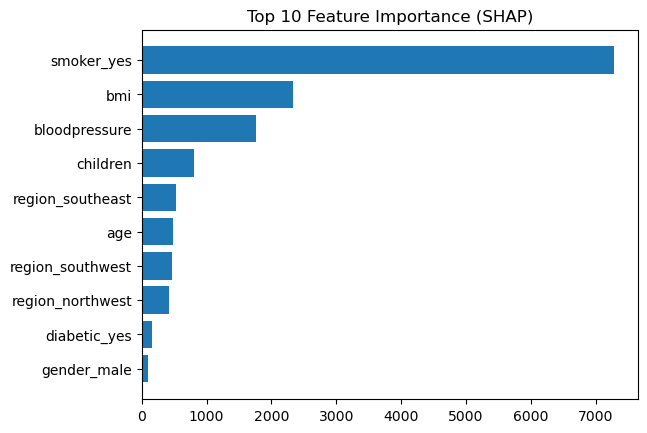

In [94]:
import matplotlib.pyplot as plt

top = feature_importance.head(10)

plt.barh(top["feature"], top["shap_importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance (SHAP)")
plt.show()

In [99]:
sample = X_test.iloc[8].copy()

In [100]:
base = xgb_model.predict([sample])[0]
print("Original Predicted Claim:", base)

Original Predicted Claim: 5008.3027


In [101]:
no_smoking = sample.copy()
no_smoking["smoker_yes"] = 0

In [102]:
new1 = xgb_model.predict([no_smoking])[0]
print("After quitting smoking:", new1)
print("Savings:", base - new1)

After quitting smoking: 5008.3027
Savings: 0.0


In [103]:
lower_bmi = sample.copy()
lower_bmi["bmi"] = lower_bmi["bmi"] - 5

In [104]:
new2 = xgb_model.predict([lower_bmi])[0]
print("After BMI reduction:", new2)
print("Savings:", base - new2)

After BMI reduction: 4314.8574
Savings: 693.4453


In [105]:
healthy = sample.copy()
healthy["smoker_yes"] = 0
healthy["bmi"] = healthy["bmi"] - 5
healthy["bloodpressure"] = healthy["bloodpressure"] - 10

In [106]:
new3 = xgb_model.predict([healthy])[0]
print("Healthy lifestyle prediction:", new3)
print("Total savings:", base - new3)

Healthy lifestyle prediction: 4150.839
Total savings: 857.46387


In [107]:
X_train.columns

Index(['age', 'bmi', 'bloodpressure', 'children', 'gender_male', 'smoker_yes',
       'diabetic_yes', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Obese', 'bmi_category_Overweight',
       'bmi_category_Underweight'],
      dtype='object')

In [108]:
import numpy as np

sample = X_test.iloc[0].copy()

base = xgb_model.predict(np.array(sample).reshape(1, -1))[0]

sample_smoke = sample.copy()
sample_smoke["smoker_yes"] = 1
smoke_pred = xgb_model.predict(np.array(sample_smoke).reshape(1, -1))[0]

sample_nosmoke = sample.copy()
sample_nosmoke["smoker_yes"] = 0
nosmoke_pred = xgb_model.predict(np.array(sample_nosmoke).reshape(1, -1))[0]

print("Base:", base)
print("Smoker:", smoke_pred)
print("Non-Smoker:", nosmoke_pred)
print("Difference:", smoke_pred - nosmoke_pred)



Base: 6158.83
Smoker: 40189.062
Non-Smoker: 6158.83
Difference: 34030.234


In [109]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-server 1.23.4 requires anyio<4,>=3.1.0, but you have anyio 4.13.0 which is incompatible.

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: C:\Users\Nasar\anaconda3\python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.2 MB 1.5 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/9.2 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.2 MB 1.4 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.2 MB 1.3 MB/s eta 0:00:07
   ------ --------------------------------- 1.6/9.2 MB 1.4 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/9.2 MB 1.2 MB/s eta 0:00:06
   --------- ------------------------------ 2.1/9.2 MB 1.2 MB/s eta 0:00:06
   ---------- ----------------------------- 2.4/9.2 MB 1.3 MB/s eta 0:00:06
   ------------ --------------------------- 2.9/9.2 MB 1.4 MB/s eta 0:00:05
   ------------- -----------------------

In [110]:
import joblib

joblib.dump(xgb_model, "model.pkl")
joblib.dump(X_train.columns, "columns.pkl")

['columns.pkl']

In [111]:
list(X_train.columns)

['age',
 'bmi',
 'bloodpressure',
 'children',
 'gender_male',
 'smoker_yes',
 'diabetic_yes',
 'region_northwest',
 'region_southeast',
 'region_southwest',
 'bmi_category_Obese',
 'bmi_category_Overweight',
 'bmi_category_Underweight']

In [112]:
import joblib

joblib.dump(xgb_model, "model.pkl")
joblib.dump(X_train.columns, "columns.pkl")

['columns.pkl']